# EV Battery Health Prediction Using ANN

## End-to-End Deep Learning Regression Project

**Goal:** Predict battery **State of Health (SOH %)** using operational and environmental battery measurements.

### Dataset
- Rows: 2,000
- Columns: 13
- Target: `SOH`
- Identifier: `BatteryID`
- Categorical feature: `BatchID`
- Numerical features: Cycle, Voltage, Current, Temperature, ChargeTime, DischargeTime, InternalResistance, Capacity, AmbientHumidity, C_Rate

### Project workflow
1. Import libraries
2. Load and inspect the dataset
3. Data quality checks
4. Exploratory Data Analysis
5. Feature/target separation
6. Train/test split
7. Preprocessing
8. ANN model creation
9. Model training
10. Evaluation with MAE, RMSE, R²
11. Prediction analysis
12. Save model and preprocessing objects
13. Streamlit deployment


In [1]:
# Optional: install packages if your environment does not have them
# Run this cell only when needed.

# !pip install pandas numpy matplotlib scikit-learn tensorflow joblib streamlit


In [25]:
# 1. Import libraries

import os
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks

print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.21.0


In [26]:
# 2. Load the dataset

df = pd.read_csv(r"C:\Users\saive\Downloads\archive (12)\battery_dataset.csv")

print("Dataset shape:", df.shape)
display(df.head())


Dataset shape: (2000, 13)


,BatteryID,BatchID,Cycle,Voltage,Current,Temperature,ChargeTime,DischargeTime,InternalResistance,Capacity,AmbientHumidity,C_Rate,SOH
0,BAT0001,BatchC,1,3.654514,0.917553,25.888505,37.618388,37.044703,0.052224,2.500157,46.924728,1.158642,100.000000
1,BAT0002,BatchD,2,3.160100,1.697440,18.323278,40.734450,114.007199,0.049553,2.491344,66.132587,1.229915,99.415837
2,BAT0003,BatchA,3,3.829972,0.989381,26.900989,50.212414,62.681933,0.050329,2.496170,49.332729,1.939330,97.695097
3,BAT0004,BatchC,4,3.954014,0.949075,28.052929,75.017814,106.023825,0.052222,2.507784,52.957813,1.599029,97.623562
4,BAT0005,BatchC,5,3.196025,0.848759,27.798952,105.639848,67.654500,0.053726,2.506310,49.671759,0.665903,98.018179


In [27]:
# 3. Dataset information

print(df.info())
print("\nColumns:")
print(df.columns.tolist())

print("\nMissing values:")
display(df.isnull().sum().to_frame("missing_values"))

print("\nDuplicate rows:", df.duplicated().sum())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   BatteryID           2000 non-null   object 
 1   BatchID             2000 non-null   object 
 2   Cycle               2000 non-null   int64  
 3   Voltage             2000 non-null   float64
 4   Current             2000 non-null   float64
 5   Temperature         2000 non-null   float64
 6   ChargeTime          2000 non-null   float64
 7   DischargeTime       2000 non-null   float64
 8   InternalResistance  2000 non-null   float64
 9   Capacity            2000 non-null   float64
 10  AmbientHumidity     2000 non-null   float64
 11  C_Rate              2000 non-null   float64
 12  SOH                 2000 non-null   float64
dtypes: float64(10), int64(1), object(2)
memory usage: 203.3+ KB
None

Columns:
['BatteryID', 'BatchID', 'Cycle', 'Voltage', 'Current', 'Temperature', 'Charge

,missing_values
BatteryID,0
BatchID,0
Cycle,0
Voltage,0
Current,0
Temperature,0
ChargeTime,0
DischargeTime,0
InternalResistance,0
Capacity,0



Duplicate rows: 0


In [28]:
# 4. Descriptive statistics

display(df.describe(include="all").T)


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
BatteryID,2000,2000,BAT0001,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
BatchID,2000,4,BatchA,525,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Cycle,2000.0,NaN,NaN,NaN,1000.5,577.494589,1.0,500.75,1000.5,1500.25,2000.0
Voltage,2000.0,NaN,NaN,NaN,3.592491,0.346469,3.000289,3.291341,3.585221,3.893895,4.199353
Current,2000.0,NaN,NaN,NaN,1.236696,0.428394,0.500046,0.871196,1.223112,1.605997,1.999337
Temperature,2000.0,NaN,NaN,NaN,25.281789,4.902033,9.902439,21.952101,25.238242,28.464827,40.965538
ChargeTime,2000.0,NaN,NaN,NaN,74.094272,25.482926,30.004754,52.697757,73.803345,95.252876,119.875559
DischargeTime,2000.0,NaN,NaN,NaN,75.210691,25.795982,30.021679,52.858818,75.158765,97.675132,119.970588
InternalResistance,2000.0,NaN,NaN,NaN,0.149986,0.057751,0.046516,0.100005,0.149887,0.20017,0.251932
Capacity,2000.0,NaN,NaN,NaN,1.999961,0.289359,1.460427,1.752301,2.001169,2.252186,2.521192


## Exploratory Data Analysis

The target is continuous (`SOH`), so this is a **regression** problem.  
We inspect the SOH distribution, relationship with cycle count, temperature, capacity, resistance, and numerical correlations.


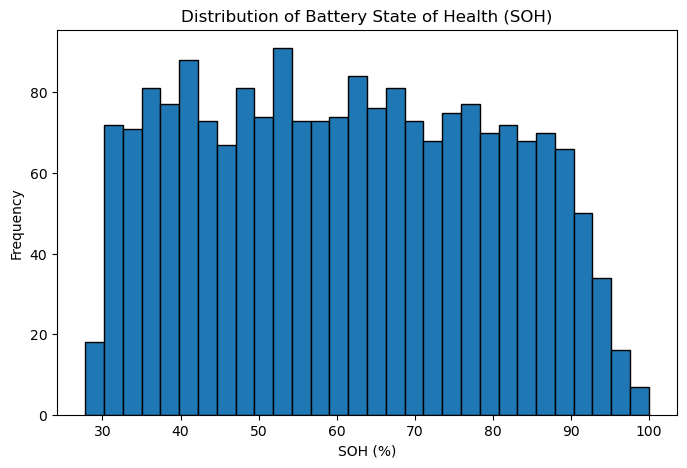

count    2000.000000
mean       61.293052
std        18.481668
min        27.791377
25%        45.290571
50%        61.085327
75%        76.830696
max       100.000000
Name: SOH, dtype: float64


In [29]:
# 5. SOH distribution

plt.figure(figsize=(8, 5))
plt.hist(df["SOH"], bins=30, edgecolor="black")
plt.title("Distribution of Battery State of Health (SOH)")
plt.xlabel("SOH (%)")
plt.ylabel("Frequency")
plt.show()

print(df["SOH"].describe())


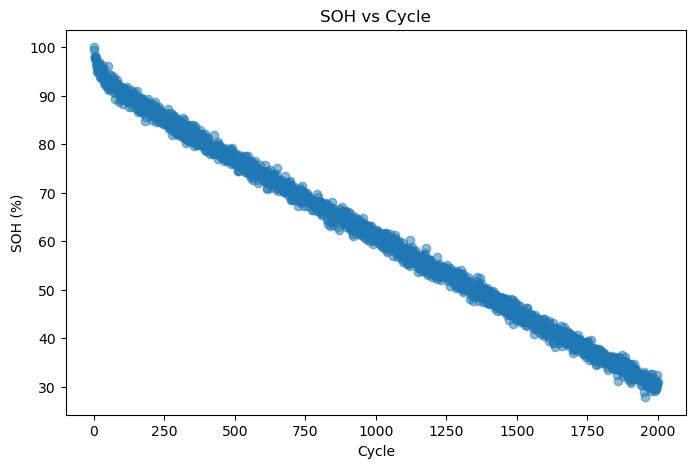

In [30]:
# 6. SOH vs Cycle

plt.figure(figsize=(8, 5))
plt.scatter(df["Cycle"], df["SOH"], alpha=0.5)
plt.title("SOH vs Cycle")
plt.xlabel("Cycle")
plt.ylabel("SOH (%)")
plt.show()


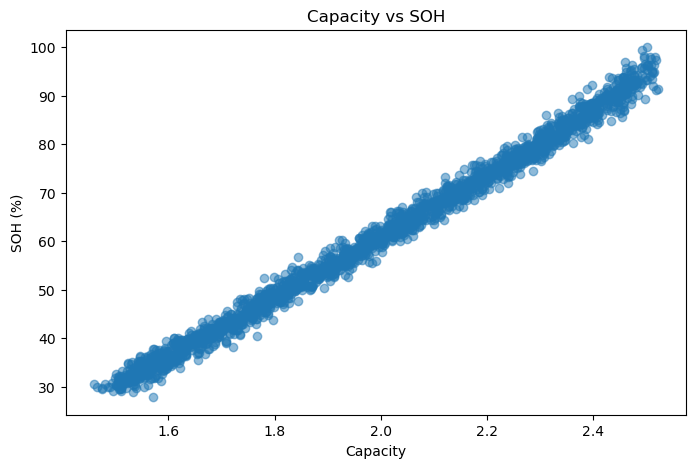

In [31]:
# 7. Capacity vs SOH

plt.figure(figsize=(8, 5))
plt.scatter(df["Capacity"], df["SOH"], alpha=0.5)
plt.title("Capacity vs SOH")
plt.xlabel("Capacity")
plt.ylabel("SOH (%)")
plt.show()


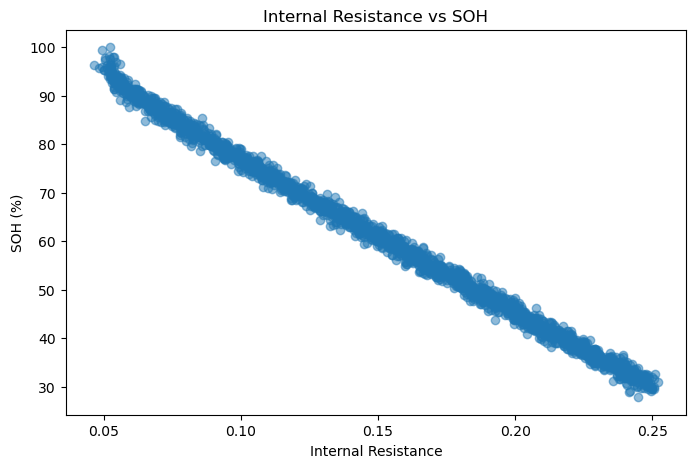

In [32]:
# 8. Internal Resistance vs SOH

plt.figure(figsize=(8, 5))
plt.scatter(df["InternalResistance"], df["SOH"], alpha=0.5)
plt.title("Internal Resistance vs SOH")
plt.xlabel("Internal Resistance")
plt.ylabel("SOH (%)")
plt.show()


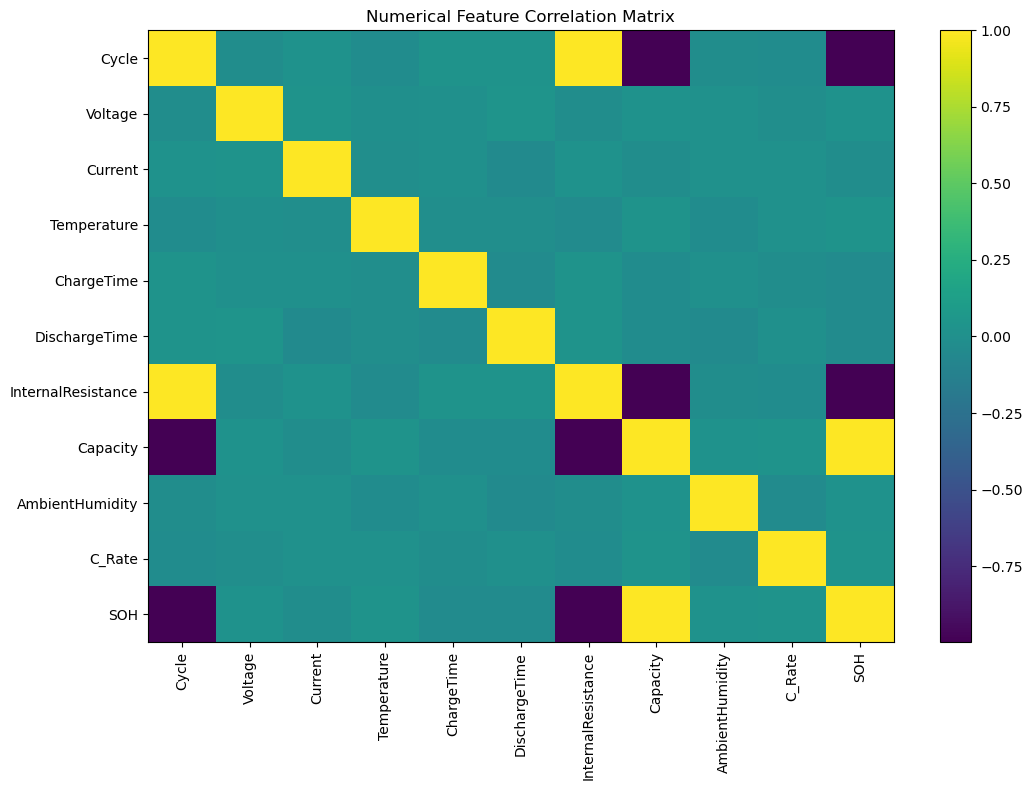

,correlation_with_SOH
SOH,1.000000
Capacity,0.995603
C_Rate,0.029101
Temperature,0.024663
AmbientHumidity,0.020385
Voltage,0.017815
Current,-0.020186
DischargeTime,-0.030286
ChargeTime,-0.030689
InternalResistance,-0.997416


In [33]:
# 9. Numerical correlation matrix

numeric_df = df.select_dtypes(include=np.number)
corr = numeric_df.corr()

plt.figure(figsize=(11, 8))
plt.imshow(corr, aspect="auto")
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Numerical Feature Correlation Matrix")
plt.tight_layout()
plt.show()

display(corr["SOH"].sort_values(ascending=False).to_frame("correlation_with_SOH"))


## Data Preprocessing

`BatteryID` is an identifier and is removed from model training.  
`BatchID` is one-hot encoded. Numerical variables are standardized using `StandardScaler`.


In [34]:
# 10. Separate features and target

TARGET = "SOH"
DROP_COLUMNS = ["BatteryID"]

X = df.drop(columns=[TARGET] + DROP_COLUMNS)
y = df[TARGET]

categorical_features = ["BatchID"]
numeric_features = [c for c in X.columns if c not in categorical_features]

print("Numerical features:", numeric_features)
print("Categorical features:", categorical_features)
print("X shape:", X.shape)
print("y shape:", y.shape)


Numerical features: ['Cycle', 'Voltage', 'Current', 'Temperature', 'ChargeTime', 'DischargeTime', 'InternalResistance', 'Capacity', 'AmbientHumidity', 'C_Rate']
Categorical features: ['BatchID']
X shape: (2000, 11)
y shape: (2000,)


In [35]:
# 11. Train/test split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))


Training rows: 1600
Testing rows: 400


In [36]:
# 12. Build preprocessing pipeline

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_features),
    ],
    remainder="drop"
)

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Processed training shape:", X_train_processed.shape)
print("Processed testing shape:", X_test_processed.shape)


Processed training shape: (1600, 14)
Processed testing shape: (400, 14)


## ANN Architecture

The network uses:
- Input layer based on processed feature count
- Dense(128, ReLU)
- Batch Normalization
- Dropout
- Dense(64, ReLU)
- Dropout
- Dense(32, ReLU)
- Output Dense(1) for continuous SOH prediction

Loss: Mean Squared Error  
Optimizer: Adam


In [37]:
# 13. Build ANN regression model

tf.random.set_seed(42)
np.random.seed(42)

model = keras.Sequential([
    layers.Input(shape=(X_train_processed.shape[1],)),
    layers.Dense(128, activation="relu"),
    layers.BatchNormalization(),
    layers.Dropout(0.25),

    layers.Dense(64, activation="relu"),
    layers.Dropout(0.20),

    layers.Dense(32, activation="relu"),

    layers.Dense(1)
])

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="mse",
    metrics=["mae"]
)

model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                      │ (None, 128)                 │           1,920 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 128)                 │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 12,801 (50.00 KB)

 Trainable params: 12,545 (49.00 KB)

 Non-trainable params: 256 (1.00 KB)

In [38]:
# 14. Training callbacks

early_stopping = callbacks.EarlyStopping(
    monitor="val_loss",
    patience=20,
    restore_best_weights=True
)

reduce_lr = callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=8,
    min_lr=1e-6
)


In [39]:
# 15. Train the ANN

history = model.fit(
    X_train_processed,
    y_train,
    validation_split=0.20,
    epochs=250,
    batch_size=32,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)


Epoch 1/250
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 3535.4043 - mae: 56.8370 - val_loss: 3378.0513 - val_mae: 55.8307 - learning_rate: 0.0010
Epoch 2/250
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1443.5392 - mae: 34.9813 - val_loss: 1634.0919 - val_mae: 39.8244 - learning_rate: 0.0010
Epoch 3/250
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 306.4680 - mae: 14.3342 - val_loss: 1195.3474 - val_mae: 33.5487 - learning_rate: 0.0010
Epoch 4/250
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 161.5623 - mae: 10.2599 - val_loss: 882.3564 - val_mae: 29.0087 - learning_rate: 0.0010
Epoch 5/250
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 129.8453 - mae: 9.0441 - val_loss: 644.0892 - val_mae: 24.7503 - learning_rate: 0.0010
Epoch 6/250
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 113.9983 - mae: 8.4507 - val_loss: 470.1680 - val_mae: 21.0103 - learning_rate: 0.0010
Epoch 7/250
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 107.2901 - mae: 8.1134 - val_loss: 269.0317 - val_mae: 1

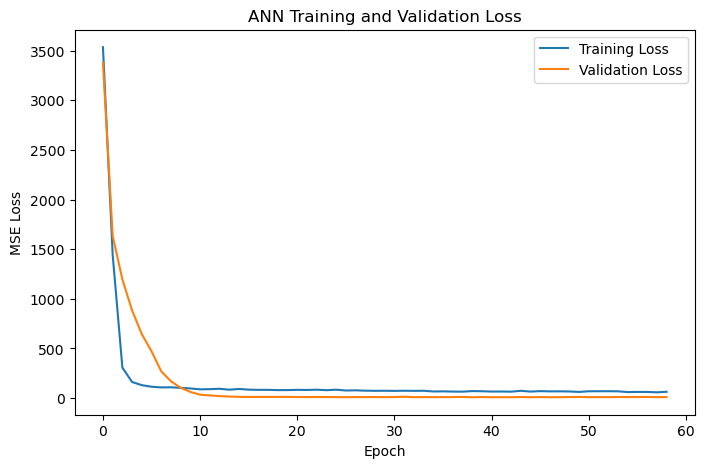

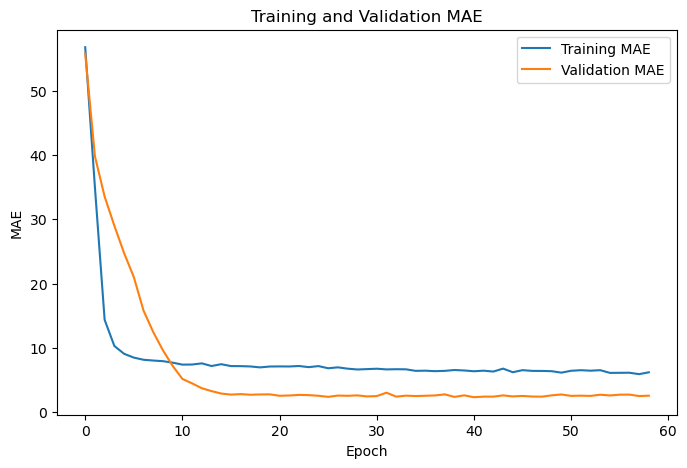

In [40]:
# 16. Plot training history

history_df = pd.DataFrame(history.history)

plt.figure(figsize=(8, 5))
plt.plot(history_df["loss"], label="Training Loss")
plt.plot(history_df["val_loss"], label="Validation Loss")
plt.title("ANN Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history_df["mae"], label="Training MAE")
plt.plot(history_df["val_mae"], label="Validation MAE")
plt.title("Training and Validation MAE")
plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.legend()
plt.show()


## Model Evaluation

For regression, the main metrics are:
- **MAE** — average absolute prediction error
- **RMSE** — penalizes larger prediction errors
- **R²** — proportion of target variance explained by the model


In [41]:
# 17. Predict on test data

y_pred = model.predict(X_test_processed, verbose=0).ravel()

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE : {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²  : {r2:.4f}")


MAE : 2.3701
RMSE: 3.0034
R²  : 0.9747


In [42]:
# 18. Actual vs predicted SOH

results = pd.DataFrame({
    "Actual_SOH": y_test.values,
    "Predicted_SOH": y_pred
})

results["Absolute_Error"] = np.abs(results["Actual_SOH"] - results["Predicted_SOH"])

display(results.head(20))


,Actual_SOH,Predicted_SOH,Absolute_Error
0,34.802248,32.927429,1.874819
1,81.786370,76.365746,5.420624
2,50.940958,47.091549,3.849409
3,63.566991,61.731136,1.835854
4,50.765508,49.500732,1.264776
5,53.459570,49.393909,4.065661
6,63.456022,58.035755,5.420267
7,39.124822,37.036983,2.087839
8,93.164424,94.705231,1.540807
9,50.923246,51.638645,0.715399


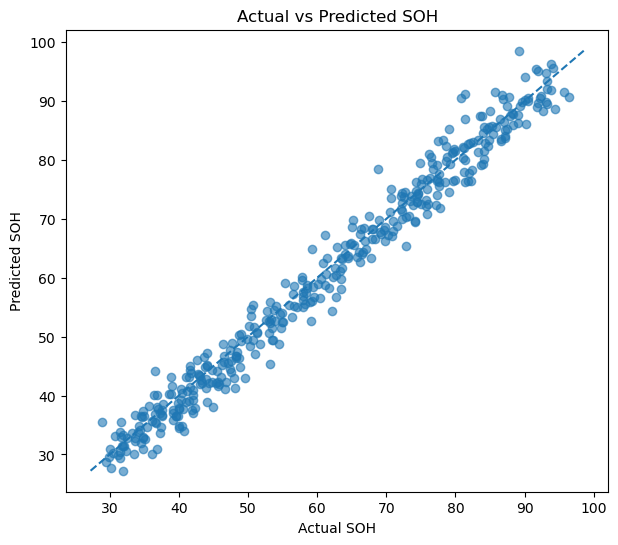

In [43]:
# 19. Actual vs predicted visualization

plt.figure(figsize=(7, 6))
plt.scatter(y_test, y_pred, alpha=0.6)

min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())

plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")
plt.title("Actual vs Predicted SOH")
plt.xlabel("Actual SOH")
plt.ylabel("Predicted SOH")
plt.show()


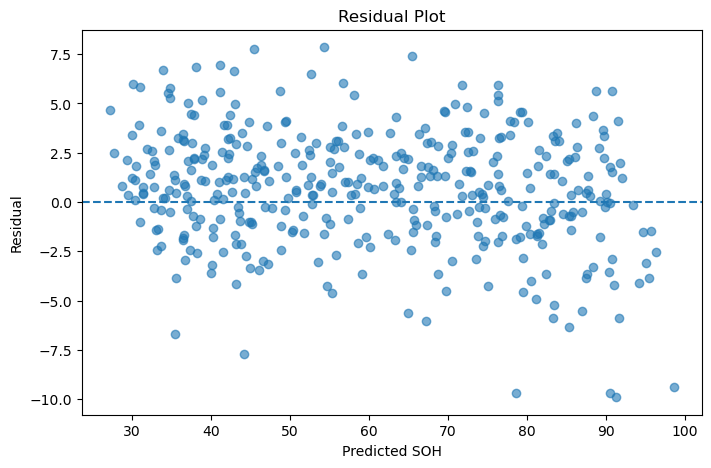

In [44]:
# 20. Residual analysis

residuals = y_test.values - y_pred

plt.figure(figsize=(8, 5))
plt.scatter(y_pred, residuals, alpha=0.6)
plt.axhline(0, linestyle="--")
plt.title("Residual Plot")
plt.xlabel("Predicted SOH")
plt.ylabel("Residual")
plt.show()


## Battery Health Interpretation

The following status bands are **illustrative project thresholds**, not manufacturer-specific diagnostic rules:

- SOH ≥ 90% → Excellent
- 80% ≤ SOH < 90% → Good
- 70% ≤ SOH < 80% → Aging
- SOH < 70% → Poor / Service Recommended


In [45]:
# 21. Helper function for battery health label

def battery_health_status(soh):
    if soh >= 90:
        return "Excellent"
    elif soh >= 80:
        return "Good"
    elif soh >= 70:
        return "Aging"
    else:
        return "Poor / Service Recommended"

results["Health_Status"] = results["Predicted_SOH"].apply(battery_health_status)
display(results.head(20))


,Actual_SOH,Predicted_SOH,Absolute_Error,Health_Status
0,34.802248,32.927429,1.874819,Poor / Service Recommended
1,81.786370,76.365746,5.420624,Aging
2,50.940958,47.091549,3.849409,Poor / Service Recommended
3,63.566991,61.731136,1.835854,Poor / Service Recommended
4,50.765508,49.500732,1.264776,Poor / Service Recommended
5,53.459570,49.393909,4.065661,Poor / Service Recommended
6,63.456022,58.035755,5.420267,Poor / Service Recommended
7,39.124822,37.036983,2.087839,Poor / Service Recommended
8,93.164424,94.705231,1.540807,Excellent
9,50.923246,51.638645,0.715399,Poor / Service Recommended


## Save Model for Deployment

The ANN model, preprocessing transformer, and deployment metadata are saved so Streamlit uses the exact same feature preparation as training.


In [46]:
# 22. Save deployment artifacts

os.makedirs("artifacts", exist_ok=True)

model.save("artifacts/battery_soh_ann.keras")
joblib.dump(preprocessor, "artifacts/preprocessor.joblib")

metadata = {
    "target": TARGET,
    "drop_columns": DROP_COLUMNS,
    "numeric_features": numeric_features,
    "categorical_features": categorical_features,
    "batch_values": sorted(df["BatchID"].dropna().astype(str).unique().tolist()),
    "metrics": {
        "mae": float(mae),
        "rmse": float(rmse),
        "r2": float(r2)
    }
}

with open("artifacts/metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

print("Saved:")
print("- artifacts/battery_soh_ann.keras")
print("- artifacts/preprocessor.joblib")
print("- artifacts/metadata.json")


Saved:
- artifacts/battery_soh_ann.keras
- artifacts/preprocessor.joblib
- artifacts/metadata.json


In [47]:
# 23. Test one prediction exactly as deployment will do

sample = X_test.iloc[[0]].copy()
sample_processed = preprocessor.transform(sample)
sample_prediction = float(model.predict(sample_processed, verbose=0).ravel()[0])

print("Input:")
display(sample)

print(f"Predicted SOH: {sample_prediction:.2f}%")
print("Health Status:", battery_health_status(sample_prediction))


Input:


,BatchID,Cycle,Voltage,Current,Temperature,ChargeTime,DischargeTime,InternalResistance,Capacity,AmbientHumidity,C_Rate
1860,BatchB,1861,3.779837,0.709175,34.046532,115.420121,30.986729,0.239761,1.564933,65.275639,1.786896


Predicted SOH: 32.93%
Health Status: Poor / Service Recommended


In [48]:
import os
import json
import joblib

os.makedirs("artifacts", exist_ok=True)

model.save("artifacts/battery_soh_ann.keras")

joblib.dump(
    preprocessor,
    "artifacts/preprocessor.joblib"
)

metadata = {
    "target": TARGET,
    "drop_columns": DROP_COLUMNS,
    "numeric_features": numeric_features,
    "categorical_features": categorical_features,
    "batch_values": sorted(
        df["BatchID"].dropna().astype(str).unique().tolist()
    ),
    "metrics": {
        "mae": float(mae),
        "rmse": float(rmse),
        "r2": float(r2)
    }
}

with open("artifacts/metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

print("Model artifacts saved successfully.")

Model artifacts saved successfully.
